
# Lab Experiment 5: Linear Regression through Gradient Descent

**Aim:** To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real world dataset.

**Objectives:**
1. Understand the concept of Gradient Descent for optimizing a Linear Regression model.
2. Preprocess the dataset before model training.
3. Implement Linear Regression using Gradient Descent.
4. Analyze the convergence of the loss function during training.
5. Evaluate the model using standard regression metrics.

**Dataset:** Student Performance Dataset (Math course), UCI Machine Learning Repository
Link: https://archive.ics.uci.edu/dataset/320/student+performance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')


## Task 1: Load the Dataset

Using the Math course file (`student-mat.csv`) from the Student Performance dataset. Values are semicolon separated.

In [2]:
df = pd.read_csv('student-mat.csv', sep=';')
print('Shape:', df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

## Task 2: Data Preprocessing

### 2.1 Missing Values

In [4]:
df.isnull().sum().sum()

np.int64(0)

The dataset has no missing values, so no imputation is needed here.

### 2.2 Encoding Categorical Variables

There are two types of categorical columns: binary (yes/no, F/M) and multi-category (like Mjob, Fjob). Binary columns are label encoded to 0/1, and multi-category columns are one-hot encoded.

In [5]:
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup',
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
multi_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

df_enc = df.copy()
for col in binary_cols:
    df_enc[col] = df_enc[col].astype('category').cat.codes

df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)
df_enc = df_enc.astype({c: int for c in df_enc.columns if df_enc[c].dtype == bool})

print('Shape after encoding:', df_enc.shape)
df_enc.head()

Shape after encoding: (395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,1,0,1,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,1,0,1,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,1,0,1,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


## Task 3: Feature and Target Selection

The target variable is **G3**, the final grade. All other columns (demographics, study habits, and the earlier grades G1, G2) are used as input features.

In [6]:
X = df_enc.drop(columns=['G3'])
y = df_enc['G3']

print('Features:', X.shape)
print('Target:', y.shape)

Features: (395, 41)
Target: (395,)


## Task 4: Train-Test Split and Feature Scaling

Split first, then scale using statistics from the training set only, so no information from the test set leaks into training.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape:', X_test_scaled.shape)

Train shape: (316, 41)
Test shape: (79, 41)


## Task 5: Linear Regression using Gradient Descent

Implemented from scratch using NumPy. The model predicts `y = Xw + b`, the cost is Mean Squared Error, and weights are updated in the direction that reduces the cost at each iteration.

In [8]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        y = np.array(y)

        for _ in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y

            cost = (1 / (2 * n_samples)) * np.sum(error ** 2)
            self.cost_history.append(cost)

            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

In [9]:
model = LinearRegressionGD(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

print('Final training cost:', round(model.cost_history[-1], 4))

Final training cost: 1.4115


## Task 6: Effect of Learning Rate on Convergence

Training the same model with different learning rates to see how the cost curve behaves.

In [10]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
lr_models = {}

for lr in learning_rates:
    m = LinearRegressionGD(learning_rate=lr, n_iterations=1000)
    m.fit(X_train_scaled, y_train)
    lr_models[lr] = m
    print(f'lr = {lr:<6} final cost = {m.cost_history[-1]:.4f}')

lr = 0.001  final cost = 9.2697
lr = 0.01   final cost = 1.4302
lr = 0.1    final cost = 1.4115
lr = 1.0    final cost = nan


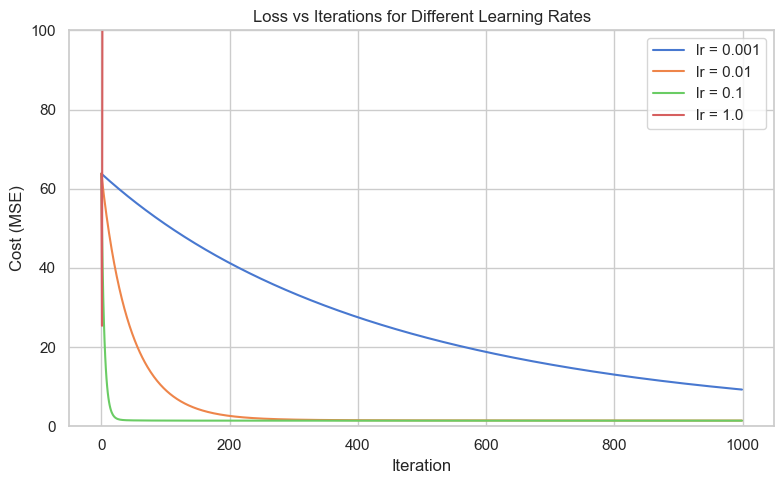

In [11]:
plt.figure(figsize=(8, 5))
for lr, m in lr_models.items():
    plt.plot(m.cost_history, label=f'lr = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Loss vs Iterations for Different Learning Rates')
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

With lr = 0.001 the cost decreases very slowly and does not fully converge in 1000 iterations. lr = 0.01 and lr = 0.1 converge smoothly to a low cost. At lr = 1.0 the updates overshoot the minimum and the cost blows up (diverges) instead of decreasing.

Based on this, lr = 0.1 gives the fastest stable convergence and is used as the final model going forward.

## Task 7: Loss Convergence of the Final Model

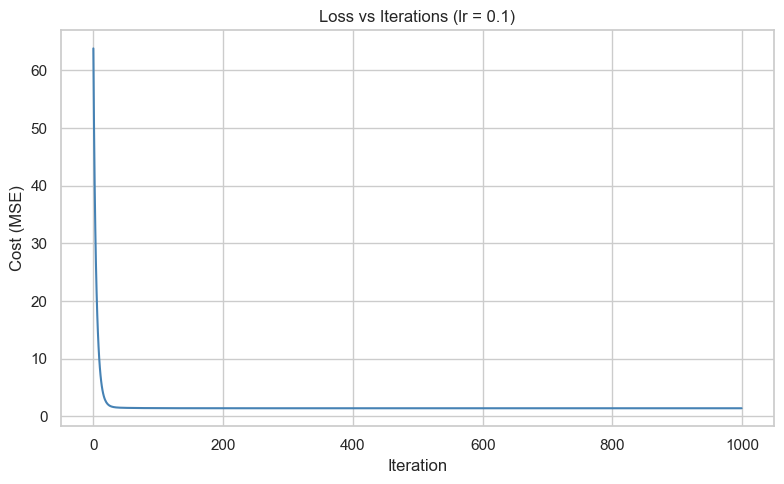

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(model.cost_history, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title(f'Loss vs Iterations (lr = {model.lr})')
plt.tight_layout()
plt.show()

The cost drops sharply in the first few iterations and then flattens out, showing that the model has converged well before reaching iteration 1000.

## Task 8: Model Evaluation

Evaluating the final model (lr = 0.1) on the test set using MAE, MSE, RMSE, and R².

In [13]:
y_pred = model.predict(X_test_scaled)

mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f'MAE  : {mae:.3f}')
print(f'MSE  : {mse:.3f}')
print(f'RMSE : {rmse:.3f}')
print(f'R2   : {r2:.3f}')

MAE  : 1.647
MSE  : 5.657
RMSE : 2.378
R2   : 0.724


An R² of around 0.72 means the model explains about 72% of the variation in the final grade. On average the predictions are off by about 1.6 to 2.4 marks, which is reasonable for a 0-20 grading scale.

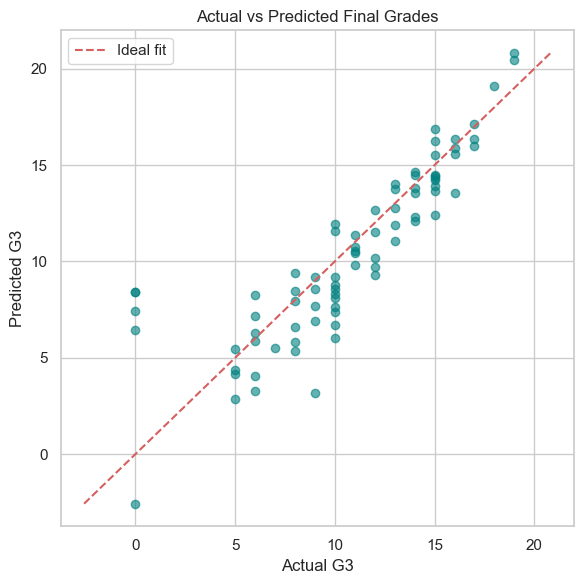

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal fit')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs Predicted Final Grades')
plt.legend()
plt.tight_layout()
plt.show()

Most points lie close to the red dashed line, meaning predicted grades are close to actual grades. A few points drift away for students with unusually low or high grades.

## Task 9: Interpretation and Conclusion

**Convergence behavior:** A learning rate that is too small (0.001) converges too slowly, a moderate one (0.01, 0.1) converges smoothly, and a large one (1.0) causes the cost to diverge instead of decreasing. This confirms that learning rate is one of the most important hyperparameters in gradient descent.

**Prediction performance:** The final model reaches an R² of about 0.72 on the test set, with an RMSE of roughly 2.4 marks. This shows Linear Regression trained with Gradient Descent captures the main trends in the data reasonably well, though some prediction error remains, likely due to factors not present in the dataset.